# Part 1 — Neural fields to Tensorweave (FTG)

## Gravity gradiometry

Airborne full-tensor gravity gradiometry (FTG) measures how gravitational acceleration changes from place to place, rather than the acceleration itself. The gravity vector is the gradient of a scalar potential, $\mathbf{g}=\nabla\varphi$. An FTG survey measures the gradient of that vector: the second derivatives $\partial^2\varphi/\partial x_i\partial x_j$, reported in Eötvös ($1\,\mathrm{E}=10^{-9}\,\mathrm{s}^{-2}$). Because gradients decay faster with distance than $\mathbf{g}$, they emphasise shallow density contrasts — ore, salt, faults, basin edges — and are less dominated by the regional field. Instruments such as Bell Geospace Air-FTG (three rotating gravity-gradiometer instruments) or a partial-tensor system such as FALCON are flown along closely spaced lines, typically a few hundred metres apart, at low altitude.

The gravity-gradient tensor is symmetric, so six components are independent: $G_{xx}$, $G_{xy}$, $G_{xz}$, $G_{yy}$, $G_{yz}$ and $G_{zz}$. Away from the source masses the field is harmonic, $G_{xx}+G_{yy}+G_{zz}=0$, which removes one further degree of freedom. The figures below show that tensor layout and a survey aircraft used to acquire it.

![Vertical gravity $G_z$ and the vertical gradient $G_{zz}$. Wikimedia Commons: *Tensors-Gz---Gzz2.jpg*.](https://upload.wikimedia.org/wikipedia/commons/c/cf/Tensors-Gz---Gzz2.jpg)

![Gravity-gradiometry survey aircraft. Wikimedia Commons / Geograph: *Gravity Gradiometry survey aircraft* (Trevor Littlewood, [CC BY-SA 2.0](https://creativecommons.org/licenses/by-sa/2.0/)).](https://upload.wikimedia.org/wikipedia/commons/9/9f/Gravity_Gradiometry_survey_aircraft_-_geograph.org.uk_-_7099689.jpg)

---------------

**Question 1**: What is the relationship between the scalar potential φ, its Hessian, and the six FTG components? Why do we not just interpolate each tensor component separately?

**Answer**: The six FTG components are the independent entries of the Hessian of $\varphi$, $H_{ij}=\partial_i\partial_j\varphi$, stored here as $(G_{xx}, G_{xy}, G_{xz}, G_{yy}, G_{yz}, G_{zz})$. They are not six unrelated scalar fields. Interpolating each component on its own can produce a tensor that is not a Hessian of any potential, and whose trace $G_{xx}+G_{yy}+G_{zz}$ is not zero. Fitting one scalar $\varphi$ and differentiating it enforces symmetry of the tensor by construction. A harmonic encoding, or a Laplacian penalty, additionally enforces Laplace's equation away from the sources.

---------------

## Notebook Outline:

In the following notebook we explore how physics-informed and physics-constrained neural fields can help interpolate full-tensor gravity gradiometry datasets from individual flight lines.

1. Setup and load flight-line full-tensor gravity gradiometry data  
2. Setup MLP potential and derive FTG prediction via autodiff Hessian  
3. Introduce random fourier features to resolve spectral bias issue  
4. Fit, and check if solution is physically possible?
5. PINN approach with physics in the loss
6. Physically constrained approach with physics in the architecture


## Step 0 — Setup

In the following we ensure all required files are on our Colab instance (if running in Colab), and define some helper functions for plotting results etc.

So... nothing exciting here --> just vanilla github and matplotlib.

In [2]:
# Running in Colab? If so, clone the workshop repo (URL supplied when the remote exists).
try:
    import google.colab  # present only inside a Colab runtime
    IN_COLAB = True
except ImportError:
    IN_COLAB = False  # local Jupyter or Cursor

WORKSHOP_REPO = "https://github.com/k4m4th/PhysInArch_HZDRAI.git"  # e.g. "https://github.com/<org>/<repo>.git"

if IN_COLAB:
    import os
    import subprocess
    from pathlib import Path

    if not WORKSHOP_REPO:
        raise RuntimeError(
            "Set WORKSHOP_REPO to the workshop GitHub URL before running on Colab."
        )
    dest = Path("/content/workshop")  # Colab's local disk
    if not (dest / "tensorweave.py").exists():
        # shallow clone: the notebook only needs the current workshop files
        subprocess.check_call(["git", "clone", "--depth", "1", WORKSHOP_REPO, str(dest)])
    os.chdir(dest)  # later cells take Path.cwd() as the workshop root
    print("Colab: using", dest.resolve())
else:
    print("Not running in Colab; using the local workshop folder.")


Colab: using /content/workshop


In [3]:
# Imports, device, and plotting helpers used by the rest of the notebook.
# tensorweave supplies the neural field, the six FTG component names, and the evaluation grid.

from __future__ import annotations

from pathlib import Path
import sys

HERE = Path.cwd().resolve()  # workshop folder (local, or /content/workshop on Colab)
if str(HERE) not in sys.path:
    sys.path.insert(0, str(HERE))  # so `import tensorweave` finds the file next to the notebook

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from tensorweave import (
    FTG_COMPONENT_NAMES,  # ("xx", "xy", "xz", "yy", "yz", "zz")
    NeuralFourierField,
    RasterGrid,
    add_ftg_noise_by_snr,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("workshop:", HERE)
print("device:", device)


def grid_extent(grid: RasterGrid):
    # imshow extent is [left, right, bottom, top] in metres
    return [float(grid.x[0]), float(grid.x[-1]), float(grid.y[0]), float(grid.y[-1])]


def tensor6_on_grid(model: NeuralFourierField, grid: RasterGrid, chunk_size=2048):
    # predict() returns the six Hessian components; chunk so the autodiff graph fits in memory
    return model.predict(grid.coords, output="tensor6", chunk_size=chunk_size)


def plot_flight_lines(ax, survey_xy, *, color="k", lw=0.6, alpha=0.85):
    """Draw each constant-y flight line as a thin polyline."""
    if survey_xy is None:
        return
    xy = np.asarray(survey_xy)
    y_key = np.round(xy[:, 1].astype(np.float64), decimals=2)  # one key per flight line
    for yv in np.unique(y_key):
        pts = xy[y_key == yv]
        order = np.argsort(pts[:, 0])  # west to east, so the stroke is continuous
        ax.plot(
            pts[order, 0],
            pts[order, 1],
            color=color,
            lw=lw,
            alpha=alpha,
            solid_capstyle="butt",
            zorder=3,  # draw above the raster
        )


def plot_grid_maps(grid, truth2d, pred2d, *, title_pred, component="zz", survey_xy=None):
    extent = grid_extent(grid)
    vmin = np.nanmin([truth2d, pred2d])  # shared colour scale for truth and prediction
    vmax = np.nanmax([truth2d, pred2d])
    fig, ax = plt.subplots(1, 3, figsize=(13, 3.8), constrained_layout=True)
    for a, data, ttl in zip(
        ax[:2],
        (truth2d, pred2d),
        (f"Truth $G_{{{component}}}$", title_pred),
    ):
        a.imshow(data, origin="lower", extent=extent, cmap="RdBu_r", vmin=vmin, vmax=vmax, aspect="equal")
        plot_flight_lines(a, survey_xy)  # thin black flight lines on the maps
        a.set_xlabel("$x$ (m)")
        a.set_ylabel("$y$ (m)")
        a.set_title(ttl)
    diff = pred2d - truth2d  # third panel is the pointwise misfit, not a third model
    dlim = np.nanmax(np.abs(diff))  # symmetric limits so zero sits in the middle of the colormap
    im = ax[2].imshow(diff, origin="lower", extent=extent, cmap="RdBu_r", vmin=-dlim, vmax=dlim, aspect="equal")
    ax[2].set_title("Pred − truth")
    ax[2].set_xlabel("$x$ (m)")
    ax[2].set_ylabel("$y$ (m)")
    fig.colorbar(im, ax=ax[2], fraction=0.046, label="Eötvös")
    fig.suptitle(f"Gridded $G_{{{component}}}$ at z = {grid.z:g} m", y=1.02)
    plt.show()

def laplacian_on_grid(model: NeuralFourierField, grid: RasterGrid, chunk_size=2048):
    """∇²φ on every grid cell centre (trace of autodiff Hessian)."""
    lap = model.predict(grid.coords, output="laplacian", chunk_size=chunk_size)
    return lap.reshape(grid.ny, grid.nx)  # predict() is flat; maps need (row, col)


def plot_laplacian_grid(grid, lap2d, *, title, survey_xy=None, vmax=None):
    extent = grid_extent(grid)
    lim = float(vmax) if vmax is not None else np.nanmax(np.abs(lap2d))
    lim = max(lim, 1e-12)  # avoid a zero-width colour scale when the field is harmonic
    fig, ax = plt.subplots(figsize=(5.5, 4.2), constrained_layout=True)
    im = ax.imshow(
        lap2d,
        origin="lower",  # row 0 is south, matching the ESRI grids
        extent=extent,
        cmap="RdBu_r",
        vmin=-lim,  # diverging scale: red and blue are opposite signs of ∇²φ
        vmax=lim,
        aspect="equal",
    )
    plot_flight_lines(ax, survey_xy)  # same flight lines as on the tensor maps
    ax.set_xlabel("$x$ (m)")
    ax.set_ylabel("$y$ (m)")
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046, label=r"$\nabla^2 \phi$")
    fig.suptitle(f"Laplacian of potential at z = {grid.z:g} m", y=1.02)
    plt.show()


workshop: /content/workshop
device: cpu


## Step 1 — Load SimPEG FTG survey

Now we have some more boring code that simply loads the ground-truth (simulated) FTG data, and extracts 200 m spaced flight lines representing our observations (and adds some component-wise noise).

In [4]:
# Load the SimPEG truth grids, then sample noisy flight lines every ~200 m in y.
# Component order matches tensorweave: xx, xy, xz, yy, yz, zz.

FTG_NAMES = FTG_COMPONENT_NAMES
SNR_DB = (20, 18, 18, 15, 17, 19)  # per-component signal-to-noise, in the same order as FTG_NAMES
SURVEY_Z = 25.0  # flight height in metres; the truth rasters are plan views at this z
DATA_DIR = HERE / "data"


def read_esri_ascii(path: Path):
    lines = path.read_text().splitlines()
    meta = {}
    for line in lines[:6]:
        # header is "key value" pairs: ncols, nrows, xllcorner, yllcorner, cellsize, NODATA
        parts = line.split()
        key = parts[0].lower()
        val = parts[1] if len(parts) > 1 else ""
        meta[key] = int(float(val)) if key in ("ncols", "nrows") else float(val)
    ncols, nrows = meta["ncols"], meta["nrows"]
    dx = float(meta["cellsize"])
    # ESRI corners are cell edges; shift by half a cell to land on centres
    x0 = float(meta["xllcorner"]) + 0.5 * dx
    y0 = float(meta["yllcorner"]) + 0.5 * dx
    x = x0 + dx * np.arange(ncols, dtype=np.float64)
    y = y0 + dx * np.arange(nrows, dtype=np.float64)
    arr = np.loadtxt(lines[6:]).reshape(nrows, ncols)
    arr = np.flipud(arr)  # ASCII rows run north to south; arrays here run south to north
    nodata = float(meta.get("nodata_value", -9999))
    arr = np.where(arr == nodata, np.nan, arr)
    return x, y, arr, dx


def load_truth_stack(data_dir: Path):
    channels: list[np.ndarray] = []
    x = y = None
    for name in FTG_NAMES:
        xi, yi, arr, dx = read_esri_ascii(data_dir / "grids" / f"truth_{name}.asc")
        if x is None:
            x, y = xi, yi  # all six rasters share one mesh
        channels.append(arr)
    truth = np.stack(channels, axis=-1).astype(np.float32)  # (ny, nx, 6)
    grid = RasterGrid(x=x, y=y, z=SURVEY_Z)
    return grid, truth


def flight_lines_from_grid(grid: RasterGrid, truth: np.ndarray, crossline_spacing=200.0, seed=42):
    stride = max(1, int(round(crossline_spacing / grid.spacing)))  # rows between lines
    idx_y = np.arange(0, grid.ny, stride)
    sub = truth[idx_y]  # keep every sample along the line, drop rows between lines
    xx, yy = np.meshgrid(grid.x, grid.y[idx_y], indexing="xy")
    coords = np.column_stack(
        [xx.ravel(), yy.ravel(), np.full(xx.size, grid.z, dtype=np.float32)]  # z is constant
    ).astype(np.float32)
    ftg = sub.reshape(-1, 6).astype(np.float32)
    ftg = add_ftg_noise_by_snr(ftg, snr_db=SNR_DB, seed=seed)  # component-wise Gaussian noise
    return coords, ftg


eval_grid, truth = load_truth_stack(DATA_DIR)  # dense truth cube, shape (ny, nx, 6)
xyz, ftg = flight_lines_from_grid(eval_grid, truth, seed=42)  # line coordinates and noisy tensor

print("evaluation grid:", eval_grid.shape, "cell size:", eval_grid.spacing, "m")
print("flight lines:", xyz.shape[0], "points,", ftg.shape[1], "components")
print("x range:", xyz[:, 0].min(), xyz[:, 0].max())
print("y range:", xyz[:, 1].min(), xyz[:, 1].max())


evaluation grid: (65, 65) cell size: 25.0 m
flight lines: 585 points, 6 components
x range: -800.0 800.0
y range: -800.0 800.0


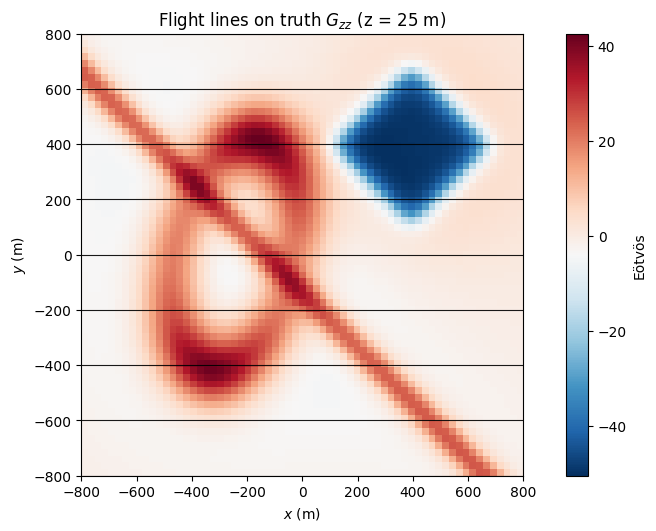

lines: 9 spacing ~ 200 m


In [5]:
# Map the flight lines on top of the true Gzz grid so the survey layout is visible.
comp = FTG_NAMES.index("zz")  # vertical gradient is the usual map to look at first
extent = grid_extent(eval_grid)
truth_zz = truth[:, :, comp]

fig, ax = plt.subplots(figsize=(7.2, 5.2), constrained_layout=True)
im = ax.imshow(
    truth_zz,
    origin="lower",  # south at the bottom, same convention as the ESRI grids
    extent=extent,
    cmap="RdBu_r",
    aspect="equal",
)
plot_flight_lines(ax, xyz, lw=0.8, alpha=0.9)  # one thin black stroke per flight line
ax.set_xlabel("$x$ (m)")
ax.set_ylabel("$y$ (m)")
ax.set_title(f"Flight lines on truth $G_{{zz}}$ (z = {eval_grid.z:g} m)")
fig.colorbar(im, ax=ax, fraction=0.046, label="Eötvös")
plt.show()

# unique rounded y values == number of lines; spacing was the 200 m stride above
print("lines:", len(np.unique(np.round(xyz[:, 1], decimals=2))), "spacing ~", 200, "m")


## Step 2 — Vanilla MLP-based neural field

Now the fun can begin.

First, we will build a simple neural field that takes an <x,y,z> coordinate as input and predicts a single scalar potential φ(x,y,z). The hessian of this field **Hessian(φ)** represents the gravity gradient tensor that we want to predict / fit to our observations along the flight lines.

And to keep things simple, we start with a vanilla MLP (no Fourier features or SIREN).


In [6]:
# Coordinate MLP: raw (x, y, z) in, scalar potential out. Fourier features stay off.
coord_mlp = NeuralFourierField(
    input_dim=3,  # input = x, y, z
    num_fourier_features=0,  # Fourier features are disabled for now (more on this later)
    hidden_layers=[256, 256],  # two layers with 256 neurons each
    harmonic=False,  # no harmonic basis (more on this later)
    activation=nn.SiLU(),  # use SiLU activation function
    seed=42,  # set the random seed for reproducibility
)

# Fit the potential so its Hessian matches the six observed FTG components on the lines.
losses, _ = coord_mlp.fit(
    xyz,  # observation coordinates
    ftg,  # observation gravity gradient tensor
    grid=eval_grid.coords,  # dense grid used when a Laplacian penalty is on (it is not, yet)
    lap=False,  # no Laplacian penalty (more on this later)
    epochs=250,  # number of training epochs
    lr=1e-3,  # learning rate
    patience=40,  # patience for early stopping
    verbose=True,  # print training progress
)

pred_ftg = coord_mlp.predict(xyz, output="tensor6")  # Hessian on the flight lines, not the grid
rmse = np.sqrt(np.mean((pred_ftg - ftg) ** 2, axis=0))  # one RMSE per tensor component
print("RMSE per component:", dict(zip(FTG_NAMES, rmse)))
print("mean RMSE:", rmse.mean())


Training: 100%|██████████| 250/250 [01:39<00:00,  2.52it/s, loss=31.8365, ftg=[6.553, 3.830, 7.421, 5.325, 5.872, 2.835], lr=1.0e-03, stall=9]

RMSE per component: {'xx': np.float64(9.505754535046767), 'xy': np.float64(5.397606503926066), 'xz': np.float64(10.841201142626119), 'yy': np.float64(8.10775841757017), 'yz': np.float64(8.594961150539843), 'zz': np.float64(4.985827851861935)}
mean RMSE: 7.905518266928483


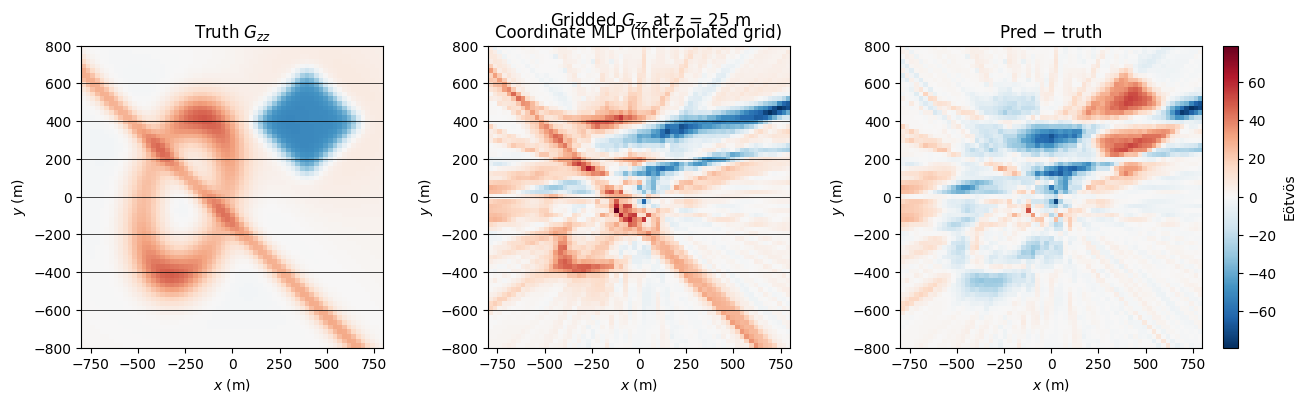

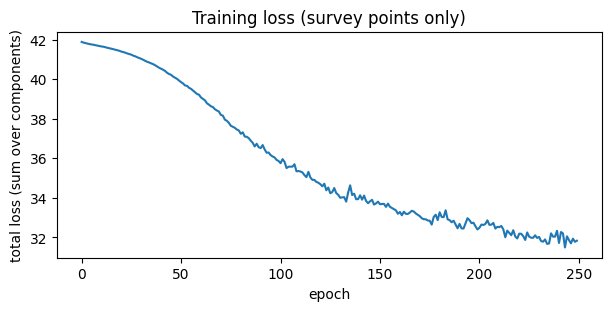

In [7]:
# Compare truth and predicted Gzz on the dense grid, then the training curve.
# plot_grid_maps draws the flight lines as thin black strokes on both maps.

comp = FTG_NAMES.index("zz")
pred_grid = tensor6_on_grid(coord_mlp, eval_grid).reshape(eval_grid.ny, eval_grid.nx, 6)
truth_comp = truth[:, :, comp]  # (ny, nx) slice of the truth cube
pred_comp = pred_grid[:, :, comp]

plot_grid_maps(
    eval_grid,
    truth_comp,
    pred_comp,
    title_pred="Coordinate MLP (interpolated grid)",
    component="zz",
    survey_xy=xyz,  # flight lines overlaid on truth and prediction
)

fig, ax = plt.subplots(figsize=(6, 3), constrained_layout=True)
ax.plot(np.asarray(losses).sum(axis=1))  # sum the six component losses into one curve
ax.set_xlabel("epoch")
ax.set_ylabel("total loss (sum over components)")
ax.set_title("Training loss (survey points only)")
plt.show()


---------------

**Question 2**: Why is this coordinate MLP struggling to match the truth grids? Can you get it to fit better by changing the MLP structure (more neurons per layer, more layers?) or activation function? What other changes (architecture, coordinates, training, or physics priors) might improve the fit?

**Answer**: A coordinate MLP is spectrally biased: with smooth activations (SiLU, tanh, ReLU) it fits the long wavelengths first and under-fits the short-wavelength structure in the gradient tensor. Extra width, extra depth, or a different smooth activation moves the loss only a little, because the network still sees raw $(x,y,z)$. The changes that matter are a positional encoding (random Fourier features, or a SIREN), enough training for that encoding, and a harmonic constraint so capacity is not spent on fields with $\nabla^2\varphi\neq 0$. The next section turns the Fourier encoding on.

---------------


## Step 3 — Introducing Random Fourier features

Now we will turn on the fourier feature encoding in our neural field, to see what changes. This new neural field predicts the same scalar potential and derived (autodiff) Hessian, but coordinates are first encoded using a fixed Sobol Fourier bank before entering the MLP.


In [8]:
# Same scalar potential as above, but (x, y, z) is first lifted into a bank of sinusoids.
# length_scales set the wavelengths of that bank; the MLP then reads the encoding, not the raw coordinates.

rff_mlp = NeuralFourierField(
    input_dim=3,
    num_fourier_features=16,  # 16 random directions, reused at each length scale
    length_scales=[2e2, 1e3],  # wavelengths of the sinusoids, in metres
    freq_damp=0.0,  # no 1/|k| damping; stacked scales ignore this anyway
    hidden_layers=[256, 256],  # same MLP width as the coordinate network
    harmonic=False,  # full 3-D wavenumbers, not the Laplace-safe bank
    potential_scale=5e6,  # output multiplier; gradients are tiny relative to metres
    activation=nn.SiLU(),
    seed=1,
)
print("uses_fourier:", rff_mlp.uses_fourier, "| scale:", float(rff_mlp.scale))

losses_rff, _ = rff_mlp.fit(
    xyz,
    ftg,
    grid=eval_grid.coords,
    lap=False,  # still a pure data fit; the Laplacian check comes next
    epochs=250,
    lr=1e-2,  # higher than the coordinate MLP; the encoding is better conditioned
    patience=40,
    verbose=True,
)

pred_ftg_rff = rff_mlp.predict(xyz, output="tensor6")  # line predictions, for the survey RMSE
rmse_rff = np.sqrt(np.mean((pred_ftg_rff - ftg) ** 2, axis=0))
print("RMSE per component:", dict(zip(FTG_NAMES, rmse_rff)))
print("mean RMSE:", rmse_rff.mean())


/tmp/ipykernel_1319/1793240777.py:15: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  print("uses_fourier:", rff_mlp.uses_fourier, "| scale:", float(rff_mlp.scale))


uses_fourier: True | scale: 4999998.0


Training: 100%|██████████| 250/250 [00:32<00:00,  7.74it/s, loss=5.9975, ftg=[0.776, 0.538, 1.148, 1.102, 0.990, 1.443], lr=4.1e-03, stall=0]

RMSE per component: {'xx': np.float64(1.0493663494265857), 'xy': np.float64(0.703192825796422), 'xz': np.float64(1.5417050286191847), 'yy': np.float64(1.4677240153061268), 'yz': np.float64(1.3072645350190064), 'zz': np.float64(1.9226064917612886)}
mean RMSE: 1.3319765409881021


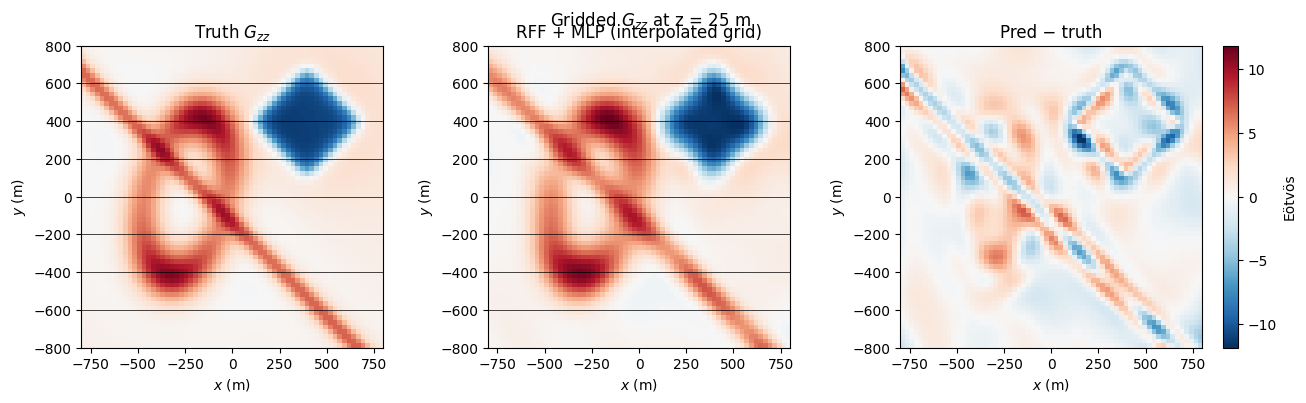

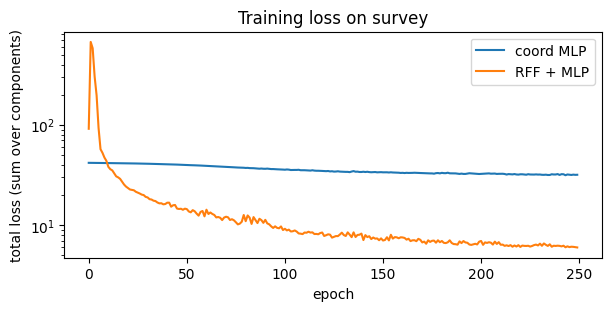

In [9]:
# Grid Gzz for the Fourier model, and compare its training curve with the coordinate MLP.

comp = FTG_NAMES.index("zz")
truth_comp = truth[:, :, comp]  # same slice the coordinate MLP was judged on
pred_grid_rff = tensor6_on_grid(rff_mlp, eval_grid).reshape(eval_grid.ny, eval_grid.nx, 6)
pred_comp_rff = pred_grid_rff[:, :, comp]  # Gzz only; the other five stay in the cube

plot_grid_maps(
    eval_grid,
    truth_comp,
    pred_comp_rff,
    title_pred="RFF + MLP (interpolated grid)",
    component="zz",
    survey_xy=xyz,  # flight lines on both maps
)

fig, ax = plt.subplots(figsize=(6, 3), constrained_layout=True)
ax.plot(np.asarray(losses).sum(axis=1), label="coord MLP")  # losses from the coordinate-MLP cell
ax.plot(np.asarray(losses_rff).sum(axis=1), label="RFF + MLP")
ax.set_xlabel("epoch")
ax.set_yscale("log")  # the Fourier loss drops by orders of magnitude
ax.set_ylabel("total loss (sum over components)")
ax.set_title("Training loss on survey")
ax.legend()
plt.show()


---------------

**Question 3**: Did the neural field using RFF encoding give better predictions? Why / how?

**Answer**: Yes. Random Fourier features map $(x,y,z)$ to $\sin(k\cdot x)$ and $\cos(k\cdot x)$ at chosen wavelengths before the MLP, so those wavelengths are available as a linear readout. That removes the spectral bias of the coordinate network: the flight-line misfit drops, and gridded $G_{zz}$ starts to follow the truth between the lines. The gain comes from the encoding, not from a deeper MLP.

**Question 4**: Try changing the `length_scales` parameter used to determine the wavelength of the sinusoids used for the encoding. How does this change the result? What happens if the length_scales are too large or too small? Which approaches might help select/chose appropriate length-scales?

**Answer**: Each entry of `length_scales` reuses the same direction bank at a different wavelength (shorter $\ell$ → shorter wavelength). Scales that are too large only produce smooth, survey-wide bumps and smear the line-to-line signal. Scales that are too small fit noise along the lines and oscillate between them. A small stack from about the line spacing ($\sim 200\,\mathrm{m}$) up to the survey width ($\sim 1\,\mathrm{km}$) is a reasonable start. Held-out flight lines, or learning the scales in log space (`learnable=True`), choose them more reliably than a single guess.

---------------


## Step 4 — The Laplacian constraint

Now that we have an apparently reasonable interpolation that fits our flight-lines quite well, we will check if it is *physically plausible*. The key physical constraint here is that for any FTG tensor (hessian of φ) the **Laplacian** ∇²φ = Gxx + Gyy + Gzz must be **zero**. This is because gravity fields outside the source are harmonic.

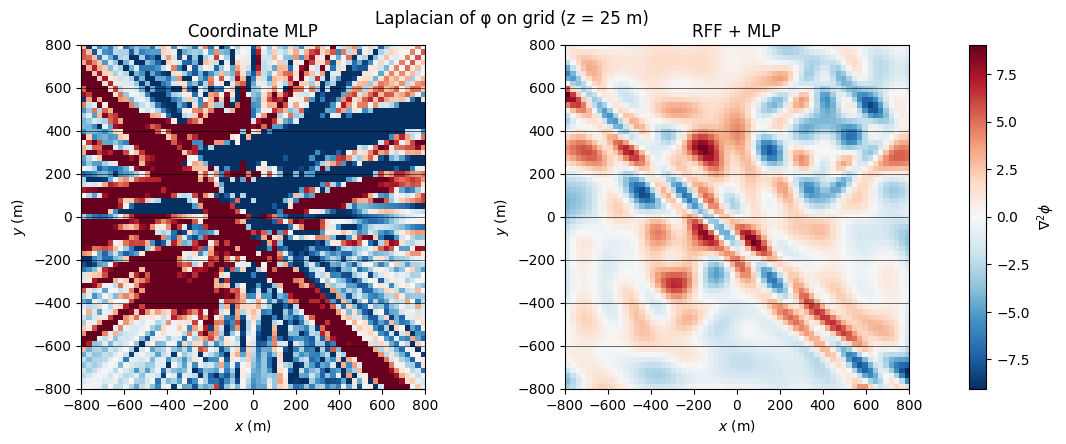

|∇²φ| mean on grid — coord MLP: 10.04011058807373 | RFF: 1.81365168094635


In [10]:
# Laplacian of each fitted potential on the dense grid.
# Outside the sources a physical field has ∇²φ = Gxx + Gyy + Gzz = 0.
lap_coord = laplacian_on_grid(coord_mlp, eval_grid)  # trace of the coordinate MLP Hessian
lap_rff = laplacian_on_grid(rff_mlp, eval_grid)  # same for the Fourier MLP

shared_lim = np.nanmax(np.abs(lap_rff))  # one colour scale so the two maps can be compared

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)
extent = grid_extent(eval_grid)  # metres, shared by both panels
for a, data, ttl in zip(
    ax,
    (lap_coord, lap_rff),
    ("Coordinate MLP", "RFF + MLP"),
):
    im = a.imshow(
        data,
        origin="lower",
        extent=extent,
        cmap="RdBu_r",  # blue and red are opposite signs of ∇²φ
        vmin=-shared_lim,
        vmax=shared_lim,
        aspect="equal",
    )
    plot_flight_lines(a, xyz, lw=0.45, alpha=0.9)  # thin black flight lines
    a.set_xlabel("$x$ (m)")
    a.set_ylabel("$y$ (m)")
    a.set_title(ttl)
fig.colorbar(im, ax=ax, fraction=0.035, label=r"$\nabla^2 \phi$")
fig.suptitle(f"Laplacian of φ on grid (z = {eval_grid.z:g} m)", y=1.02)
plt.show()

print(
    "|∇²φ| mean on grid — coord MLP:", float(np.nanmean(np.abs(lap_coord))),
    "| RFF:", float(np.nanmean(np.abs(lap_rff))),  # smaller is closer to a physical field
)


Clearly the Laplacian is not zero everywhere, even for the RFF neural field that appears to honour our observations quite well.

---------------

**Question 5**: Where is $|\nabla^2\varphi|$ largest on the map, and why? What does that say about fitting FTG on lines only, without a Laplacian term?

**Answer**: $|\nabla^2\varphi|$ is largest between the flight lines, and along sharp lateral changes that the lines only sample in passing. On the lines the tensor is pinned to the observations, so the trace stays smaller; off the lines the network is free to invent curvature. A fit to the lines alone can therefore look excellent in the survey RMSE and still be physically impossible on the grid. A Laplacian term, or a harmonic architecture, is what constrains those gaps.

---------------


## Step 5 — The PINN approach: penalising the Laplacian in the loss

It is clear that our neural field generates predictions that appear good, but are physically impossible.

To encourage physical correctness, we will now upgrade our neural field to a PINN that introduces our physical rules by penalising solutions in which the laplacian is not zero everywhere.

Note that these "global" constraints are quite hard to enforce, as during training we need to sample in many non-data locations, compute the laplacian, and then accumulate the associated loss. This sampling is done (in this case) using **Poisson-disk** to ensure a reasonable spatial distribution across the domain (and randomly resampled each epoch to ensure good coverage of the whole space).


In [11]:
# Same Fourier MLP, but fit() now adds a Laplacian penalty on Poisson-disk collocation points.
# lap_hyperparam is the weight of that penalty relative to the six-component data misfit.

LAP_SPACING = 100.0  # m, minimum spacing of the collocation points
LAP_SAMPLES = 2000  # how many of those points are drawn each epoch

rff_mlp_lap = NeuralFourierField(
    input_dim=3,
    num_fourier_features=16,  # same encoding as the data-only RFF model
    length_scales=[2e2, 1e3],
    freq_damp=0.0,
    hidden_layers=[256, 256],
    harmonic=False,  # the field can still be non-harmonic; the loss only discourages it
    potential_scale=5e6,
    activation=nn.SiLU(),
    seed=1,  # same seed as the data-only run, so the comparison is the penalty
)

losses_rff_lap, lap_counts = rff_mlp_lap.fit(
    xyz,
    ftg,
    grid=eval_grid.coords,  # bounding box the Poisson disk is drawn inside
    lap=True,
    lap_hyperparam=1.25,  # weight of the Laplacian penalty
    lap_spacing=LAP_SPACING,
    lap_samples=LAP_SAMPLES,
    epochs=250,
    lr=1e-2,
    patience=40,
    verbose=True,
)

pred_ftg_lap = rff_mlp_lap.predict(xyz, output="tensor6")
rmse_lap = np.sqrt(np.mean((pred_ftg_lap - ftg) ** 2, axis=0))  # line misfit, not the grid Laplacian
print("RMSE per component (lap=True):", dict(zip(FTG_NAMES, rmse_lap)))
print("mean RMSE:", rmse_lap.mean())
print("collocation points (last epoch):", lap_counts[-1] if lap_counts else 0)


Training: 100%|██████████| 250/250 [00:47<00:00,  5.24it/s, loss=20.5518, ftg=[2.871, 1.769, 3.810, 2.684, 2.800, 5.204], lr=1.0e-02, stall=0, lap=1.413e+00]


RMSE per component (lap=True): {'xx': np.float64(4.082569196322017), 'xy': np.float64(2.7980785048592356), 'xz': np.float64(5.296127993017921), 'yy': np.float64(3.7858326080236346), 'yz': np.float64(4.072072489711443), 'zz': np.float64(7.489977366218533)}
mean RMSE: 4.587443026358797
collocation points (last epoch): 200


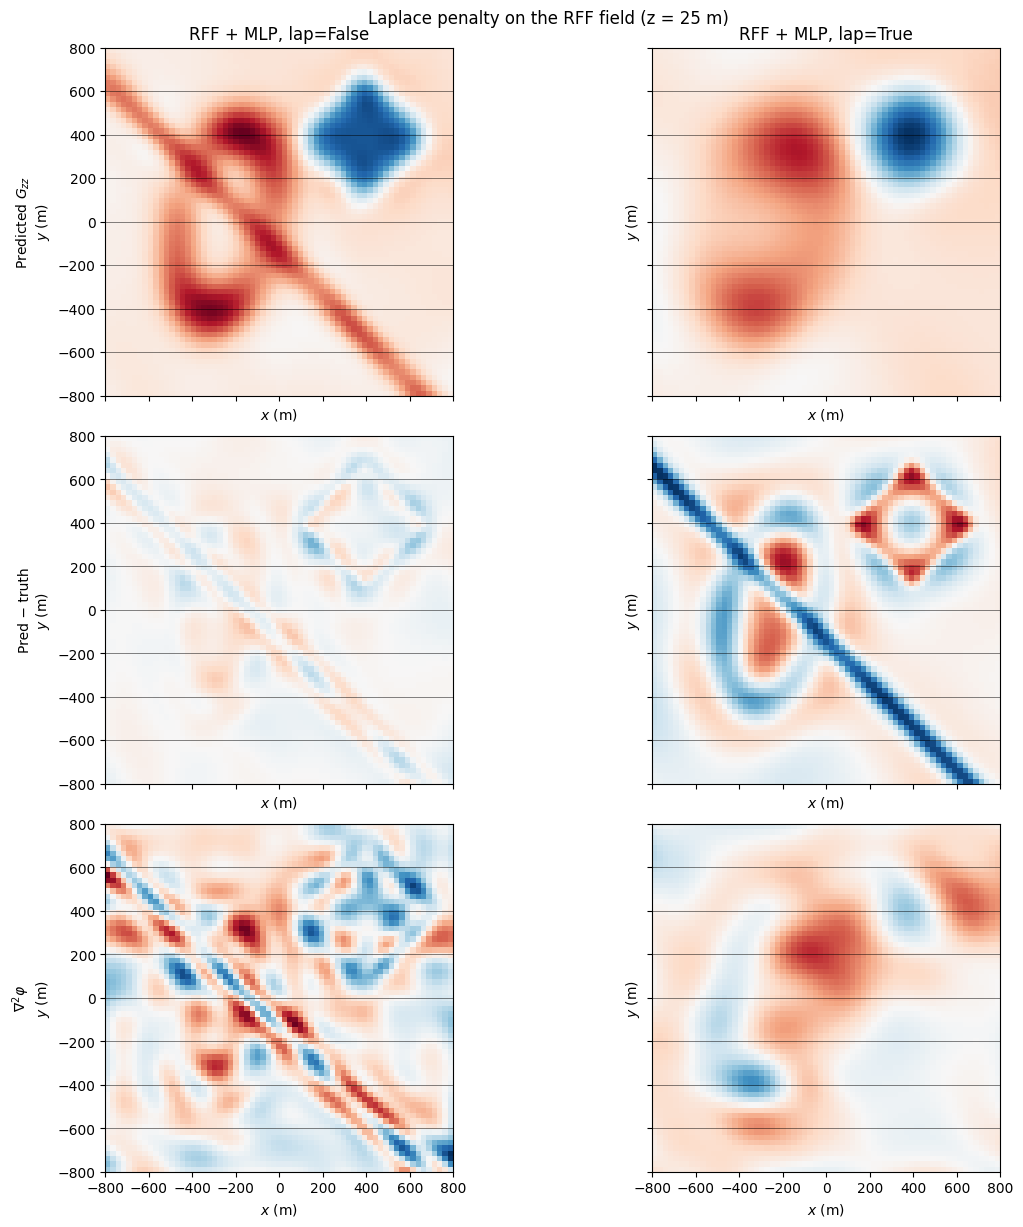

mean |∇²φ| on grid — lap=False: 1.81365168094635 | lap=True: 1.450412392616272
mean survey RMSE — lap=False: 1.3319765409881021 | lap=True: 4.587443026358797


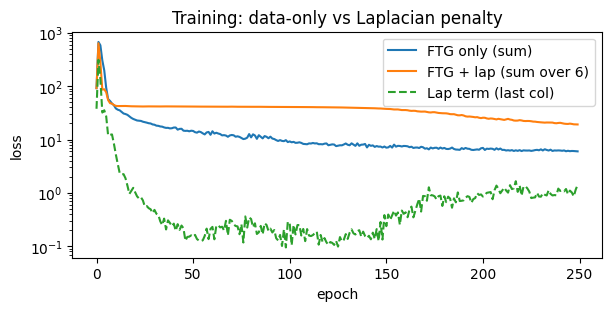

In [12]:
# Three rows (predicted Gzz, misfit, Laplacian) and two columns (no penalty vs penalty).
comp = FTG_NAMES.index("zz")  # compare the vertical gradient; the penalty acts on the trace
pred_grid_rff = tensor6_on_grid(rff_mlp, eval_grid).reshape(eval_grid.ny, eval_grid.nx, 6)
pred_grid_lap = tensor6_on_grid(rff_mlp_lap, eval_grid).reshape(eval_grid.ny, eval_grid.nx, 6)
lap_rff_lap = laplacian_on_grid(rff_mlp_lap, eval_grid)  # lap_rff was computed in the previous check

truth_zz = truth[:, :, comp]
preds = (pred_grid_rff[:, :, comp], pred_grid_lap[:, :, comp])  # column 0, then column 1
laps = (lap_rff, lap_rff_lap)
titles = ("RFF + MLP, lap=False", "RFF + MLP, lap=True")

pred_vmin = np.nanmin([truth_zz, *preds])  # one Gzz scale for both columns
pred_vmax = np.nanmax([truth_zz, *preds])
misfits = tuple(p - truth_zz for p in preds)
misfit_lim = max(np.nanmax(np.abs(misfits)), 1e-12)  # symmetric about zero
lap_lim = max(np.nanmax(np.abs(laps)), 1e-12)
extent = grid_extent(eval_grid)

fig, ax = plt.subplots(3, 2, figsize=(11, 12), sharex=True, sharey=True, constrained_layout=True)
# each column is one model; rows share a colour scale so the penalty's effect is visible
for col, (pred, misfit, lap, ttl) in enumerate(zip(preds, misfits, laps, titles)):
    ax[0, col].imshow(  # row 0: predicted Gzz
        pred, origin="lower", extent=extent, cmap="RdBu_r",
        vmin=pred_vmin, vmax=pred_vmax, aspect="equal",
    )
    ax[0, col].set_title(ttl)
    ax[1, col].imshow(  # row 1: pred − truth
        misfit, origin="lower", extent=extent, cmap="RdBu_r",
        vmin=-misfit_lim, vmax=misfit_lim, aspect="equal",
    )
    ax[2, col].imshow(  # row 2: Laplacian of that same field
        lap, origin="lower", extent=extent, cmap="RdBu_r",
        vmin=-lap_lim, vmax=lap_lim, aspect="equal",
    )
    for row in range(3):
        plot_flight_lines(ax[row, col], xyz, lw=0.4, alpha=0.85)  # same lines on every panel
        ax[row, col].set_xlabel("$x$ (m)")
        ax[row, col].set_ylabel("$y$ (m)")

ax[0, 0].set_ylabel(r"Predicted $G_{zz}$" + "\n$y$ (m)")  # row labels sit on the left column only
ax[1, 0].set_ylabel("Pred − truth\n$y$ (m)")
ax[2, 0].set_ylabel(r"$\nabla^2\varphi$" + "\n$y$ (m)")
fig.suptitle(f"Laplace penalty on the RFF field (z = {eval_grid.z:g} m)", y=1.01)
plt.show()

print(
    "mean |∇²φ| on grid — lap=False:", float(np.nanmean(np.abs(lap_rff))),
    "| lap=True:", float(np.nanmean(np.abs(lap_rff_lap))),
)
print("mean survey RMSE — lap=False:", float(rmse_rff.mean()), "| lap=True:", float(rmse_lap.mean()))

fig, ax = plt.subplots(figsize=(6, 3), constrained_layout=True)
loss_no = np.asarray(losses_rff)  # columns are the six FTG components
loss_yes = np.asarray(losses_rff_lap)  # same six, plus a Laplacian column when lap=True
ax.plot(loss_no[:, :6].sum(axis=1), label="FTG only (sum)")
if loss_yes.shape[1] > 6:
    ax.plot(loss_yes[:, :6].sum(axis=1), label="FTG + lap (sum over 6)")
    ax.plot(loss_yes[:, 6], label="Lap term (last col)", linestyle="--")  # the penalty itself
else:
    ax.plot(loss_yes.sum(axis=1), label="FTG + lap (total)")
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.set_yscale("log")
ax.set_title("Training: data-only vs Laplacian penalty")
ax.legend()
plt.show()


---------------

**Question 6**: Did this approach work? Why can $|\nabla^2\varphi|$ still be non-zero on the grid after training? What trade-off do you see between survey RMSE and mean $|\nabla^2\varphi|$?

**Answer**: The penalty reduces the mean $|\nabla^2\varphi|$, but it does not drive it to zero. The loss only sees a finite Poisson-disk set of collocation points, the penalty weight is finite, and early stopping can leave a residual, so the grid — which is denser than those points — still shows a non-zero trace. Raising the penalty usually increases the survey RMSE: data fit and Laplace consistency compete, and a soft penalty cannot satisfy both exactly.

**Question 7**: We now have a hyperparameter (`lap_hyperparam`) that sets the relative importance of the data misfit and a non-zero Laplacian. Can you find a better value, or a strategy for choosing it?

**Answer**: Too small a weight leaves the field non-harmonic; too large a weight ignores the flight lines. A short sweep, scoring both survey RMSE and grid $|\nabla^2\varphi|$ on a held-out line, finds the knee of that curve more honestly than one hand-picked number. Adaptive schemes (increase the penalty after the data loss has plateaued, or treat the two terms as a multi-objective) are more stable still. The next section removes the weight entirely by building Laplace's equation into the architecture.

---------------


## Step 6 — Moving physics into the architecture using a Harmonic fourier encoding

The PINN approach of including the physics loss in the architecture is clearly a mess: convergence is hugely sensitive to the choice of hyperparameter, with no obvious approach for rigerously determining or optimising it.

Hence, instead of this messy multi-objective optimisation, we will now test a different physics-in the architecture approach.

This changes the structure of the network (simplifying it to a single layer and removing the non-linear activation function) and changes the positional (fourier) encoding to mathematically *guarantee* that every prediction of the neural field (including its initial state) has a laplacian of zero.

In essence, we have changed the "space" that the neural network lives in so that all possible solutions are physically plausible, leaving it to focus on the data-fitting aspect alone.


In [13]:
# Harmonic Fourier head: every representable potential has ∇²φ = 0, so there is no Laplacian weight.
# The head is linear (no hidden layers, no activation); curvature comes only from the encoding.

harmonic_field = NeuralFourierField(
    input_dim=3,
    num_fourier_features=1024,  # many modes, because the head cannot add its own frequencies
    length_scales=[5e1, 1e3, 0.1e3],  # short, survey-scale, and intermediate wavelengths
    freq_damp=0.0,
    harmonic=True,  # horizontal k only, with exp(-z |k|) so Laplace's equation holds
    hidden_layers=None,  # a non-linear head would leave the harmonic subspace
    potential_scale=5e6,
    activation=None,  # ignored when there are no hidden layers; set explicitly
    seed=42,
)

print("linear head:", harmonic_field.is_linear, "| harmonic:", harmonic_field.harmonic)

losses_harm, _ = harmonic_field.fit(
    xyz,
    ftg,
    grid=eval_grid.coords,
    lap=False,  # unnecessary: the architecture already enforces ∇²φ = 0
    epochs=250,
    lr=1e-2,
    patience=40,
    verbose=True,
)

pred_ftg_harm = harmonic_field.predict(xyz, output="tensor6")  # analytic Hessian, not autodiff
rmse_harm = np.sqrt(np.mean((pred_ftg_harm - ftg) ** 2, axis=0))
print("RMSE per component:", dict(zip(FTG_NAMES, rmse_harm)))
print("mean RMSE:", rmse_harm.mean())


linear head: True | harmonic: True


Training: 100%|██████████| 250/250 [00:17<00:00, 14.03it/s, loss=11.5780, ftg=[1.422, 1.590, 1.953, 1.800, 2.312, 2.501], lr=8.0e-03, stall=0]

RMSE per component: {'xx': np.float64(1.964713032152231), 'xy': np.float64(2.2327483363343674), 'xz': np.float64(2.6563184345276927), 'yy': np.float64(2.364885521115735), 'yz': np.float64(3.2469624835246074), 'zz': np.float64(3.4898626049327652)}
mean RMSE: 2.6592484020978997


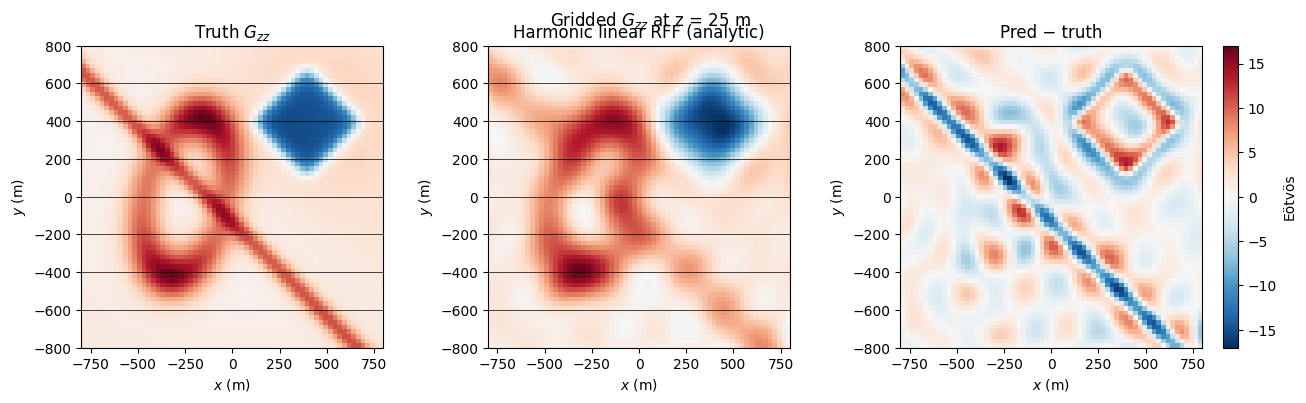

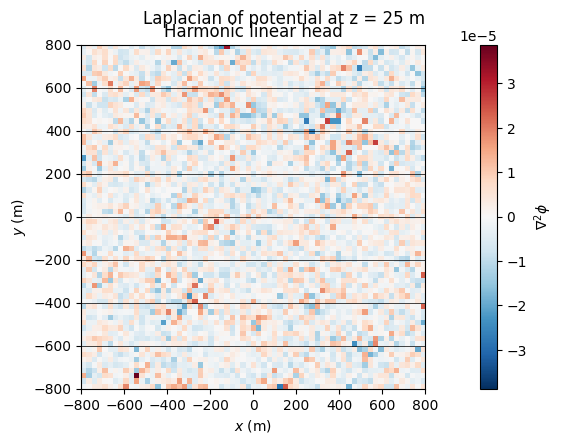

mean |∇²φ| on grid (expect ~0): 4.955447366228327e-06 | max: 3.8743019104003906e-05


In [14]:
# Gzz and the Laplacian of the harmonic field. The Laplacian should be ~0 up to floating-point error.

lap_harm = laplacian_on_grid(harmonic_field, eval_grid)  # should be numerical noise, not geology
comp = FTG_NAMES.index("zz")
pred_grid_harm = tensor6_on_grid(harmonic_field, eval_grid).reshape(eval_grid.ny, eval_grid.nx, 6)  # (ny, nx, 6)

plot_grid_maps(
    eval_grid,
    truth[:, :, comp],
    pred_grid_harm[:, :, comp],
    title_pred="Harmonic linear RFF (analytic)",
    component="zz",
    survey_xy=xyz,  # flight lines on truth and prediction
)

plot_laplacian_grid(
    eval_grid,
    lap_harm,
    title="Harmonic linear head",
    survey_xy=xyz,  # lines show where the data actually constrained the field
)

print(
    "mean |∇²φ| on grid (expect ~0):",
    float(np.nanmean(np.abs(lap_harm))),
    "| max:", float(np.nanmax(np.abs(lap_harm))),  # residual is round-off, not a real source
)


The resulting predictions now have a laplacian close to zero everywhere (with only some precision-related error creeping in). The network was also able to converge on a solution that also fits our flight-line observations quite well - in spite of its strong linearity.

---------------

**Question 8**: Although this is now a physically plausible solution that fits the flight lines reasonably well, the line misfit is higher than for a non-physical solution. Why, and what does that imply?

**Answer**: The harmonic model can only represent fields with $\nabla^2\varphi=0$. Noise on the lines, and the fact that a line sample is not exactly a harmonic tensor, give a non-physical network extra degrees of freedom it can use to over-fit. Its lower RMSE is therefore not a better interpolation. The harmonic misfit is the cost of refusing those degrees of freedom; the grid, not the line RMSE, is what can be trusted between the lines.

**Question 9**: The MLP is now a single linear layer with no activation. Where does the non-linearity in the solution come from?

**Answer**: From the Fourier encoding, not from the layer. $\varphi$ is a linear combination of $\sin(k\cdot x)$ and $\cos(k\cdot x)$ (and, in the harmonic bank, of the exponential decay with height). Those basis functions are already curved, so a linear readout of them is a non-linear function of $(x,y,z)$. A non-linear head would leave the span of harmonic functions, which is why the activation and the hidden layers were removed.

**Question 10**: How might this physics-in-the-architecture network be improved to get a better fit?

**Answer**: Stay inside the harmonic subspace and enrich the basis: more Fourier modes, a wider or learned set of length scales, and mild damping of the highest wavenumbers so short wavelengths are used only where the lines support them. A deeper non-linear MLP cannot be dropped back in unchanged, because it would no longer guarantee $\nabla^2\varphi=0$. Amplitude regularisation, and checking misfit on held-out lines rather than on the training lines, is what keeps a richer basis from fitting noise.

---------------
